# Install and Import

In [23]:
import pandas as pd
import networkx as nx
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import community as community_louvain
from collections import defaultdict
import matplotlib.cm as cm

# Preprocessing and EDA

In [24]:
artists = pd.read_csv("artists.csv")
relationships = pd.read_csv("relationships.csv")
institutions = pd.read_csv("institutions.csv")
schools = pd.read_csv("schools.csv")
artists.head()

,artistUrl,id,image,nation,title,totalWorksTitle,year
0,/en/ancient-egyptian-painting,5d230b31edc2c9fb74ae130a,https://uploads2.wikiart.org/00244/images/anci...,Egyptians,Ancient Egypt,169 artworks,c.3150 BC - c.640 AD
1,/en/ancient-greek-pottery,5ced09b1edc2c993247c1ea0,https://uploads7.wikiart.org/00238/images/anci...,Greeks,Ancient Greek Pottery,87 artworks,c.900 - 31 BC
2,/en/ancient-greek-painting,5ce3c54dedc2c921c4035b7d,https://uploads8.wikiart.org/00237/images/anci...,Greeks,Ancient Greek Painting and Sculpture,76 artworks,c.700 - c.31 BC
3,/en/apelles,5ba232ccedc2c918cc654ea8,https://uploads2.wikiart.org/00202/images/apel...,Greek,Apelles,8 artworks,born c.370 BC
4,/en/fayum-portrait,5beea1ededc2c915a01acdda,https://uploads7.wikiart.org/00210/images//01....,Egyptians,Fayum portrait,76 artworks,c.50 - c.250


In [25]:
print("=== Artists ===")
print(artists.isnull().sum())
print("\n=== Relationships ===")
print(relationships.isnull().sum())
print("\n=== Institutions ===")
print(institutions.isnull().sum())
print("\n=== Schools ===")
print(schools.isnull().sum())

=== Artists ===
artistUrl           0
id                  0
image               0
nation             32
title               0
totalWorksTitle     0
year                1
dtype: int64

=== Relationships ===
artistUrl           0
friends          2580
influenced_by    2512
influenced_on    2637
institution      2362
movements          40
school           1966
type                1
dtype: int64

=== Institutions ===
city       2
country    2
title      0
url        0
dtype: int64

=== Schools ===
title    0
url      0
dtype: int64


In [26]:
artists['nation'] = artists['nation'].fillna('Unknown')
relationships['movements'] = relationships['movements'].fillna('')
institutions['country'] = institutions['country'].fillna('Unknown')

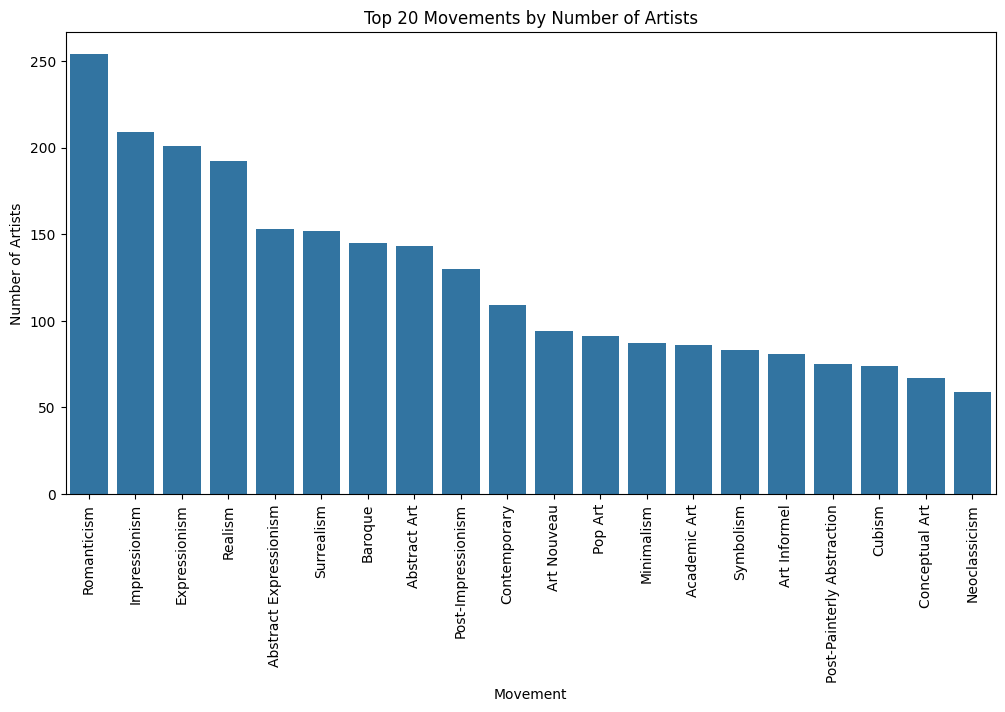

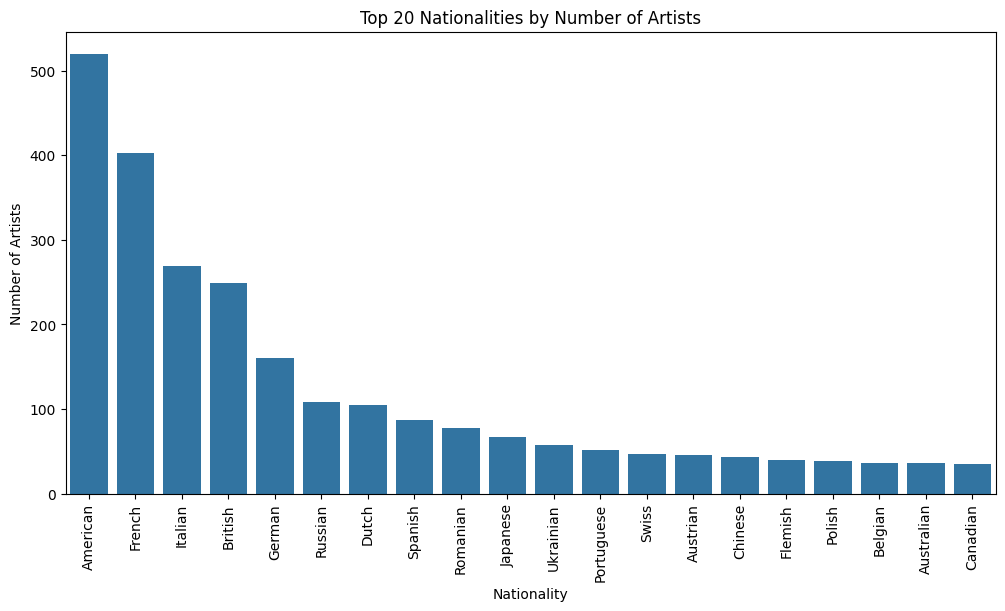

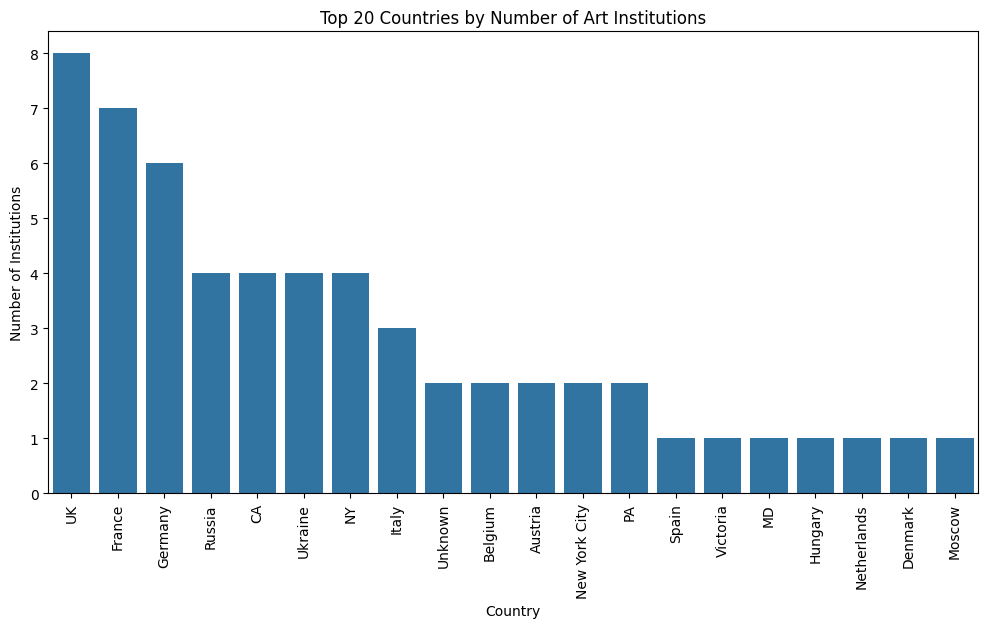

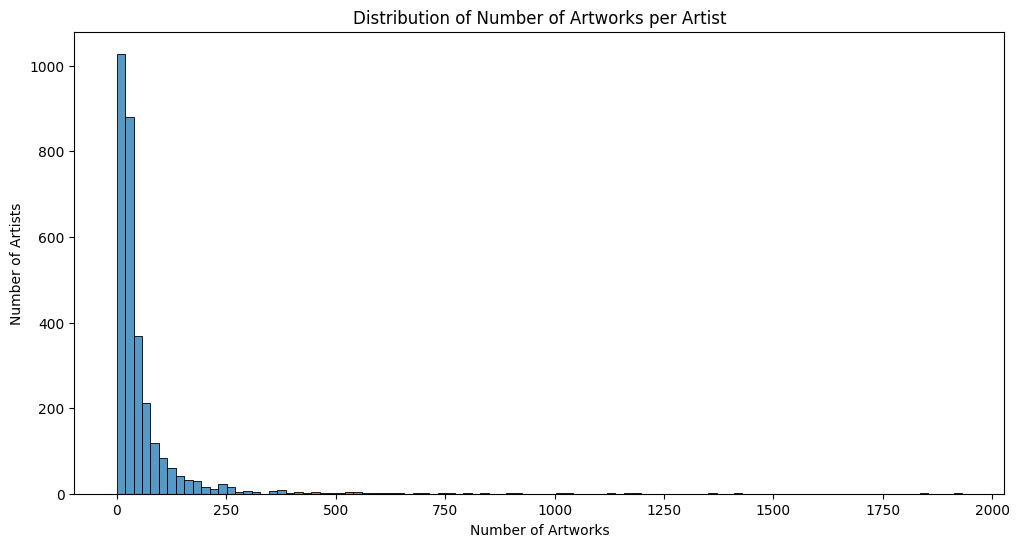

In [27]:
relationships['movements_list'] = relationships['movements'].apply(lambda x: x.split(','))
movements_exploded = relationships.explode('movements_list')
movement_counts = movements_exploded['movements_list'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=movement_counts.index[:20], y=movement_counts.values[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Movements by Number of Artists")
plt.ylabel("Number of Artists")
plt.xlabel("Movement")
plt.show()



nationality_counts = artists['nation'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=nationality_counts.index[:20], y=nationality_counts.values[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Nationalities by Number of Artists")
plt.ylabel("Number of Artists")
plt.xlabel("Nationality")
plt.show()


country_counts = institutions['country'].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=country_counts.index[:20], y=country_counts.values[:20])
plt.xticks(rotation=90)
plt.title("Top 20 Countries by Number of Art Institutions")
plt.xlabel("Country")
plt.ylabel("Number of Institutions")
plt.show()



artists['totalWorksTitle'] = pd.to_numeric(artists['totalWorksTitle'].apply(lambda x: x.split()[0]) , errors='coerce').fillna(0)

plt.figure(figsize=(12,6))
sns.histplot(artists['totalWorksTitle'], bins=100, kde=False)
plt.title("Distribution of Number of Artworks per Artist")
plt.xlabel("Number of Artworks")
plt.ylabel("Number of Artists")
plt.show()


# Question 1
**Which were the most influential artists?**

In [28]:
G = nx.DiGraph()
for _, row in artists.iterrows():
    G.add_node(row['artistUrl'],
               traitlets=row['title'],
               nation=row['nation'],
               artworks=row['totalWorksTitle'],
               active_years=row['year'])

In [29]:
for _, row in relationships.iterrows():
    if row['type']!='Artists':
      continue
    artist_url = row['artistUrl']
    try:
        influenced_by_list = row['influenced_by'].split(',') if isinstance(row['influenced_by'], str) else []
    except (ValueError, SyntaxError):
        influenced_by_list = []

    try:
        influenced_on_list = row['influenced_on'].split(',') if isinstance(row['influenced_on'], str) else []
    except (ValueError, SyntaxError):
        influenced_on_list = []

    for influencer in influenced_by_list:
          G.add_edge(influencer, artist_url)

    for influenced in influenced_on_list:
          G.add_edge(artist_url, influenced)

In [30]:
def visualize_graph(G, title, node_size=80, figsize=(14, 10), font_size=9, spacing=0.7):

    pos = nx.spring_layout(G, k=spacing, iterations=100, seed=42)

    plt.figure(figsize=figsize)
    nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=8, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color='cornflowerblue', alpha=0.9, edgecolors='white', linewidths=0.5)

    if G.number_of_nodes() <= 80:
        nx.draw_networkx_labels(G, pos, font_size=font_size, font_weight='bold')

    plt.title(title, fontsize=14, pad=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Visualized {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


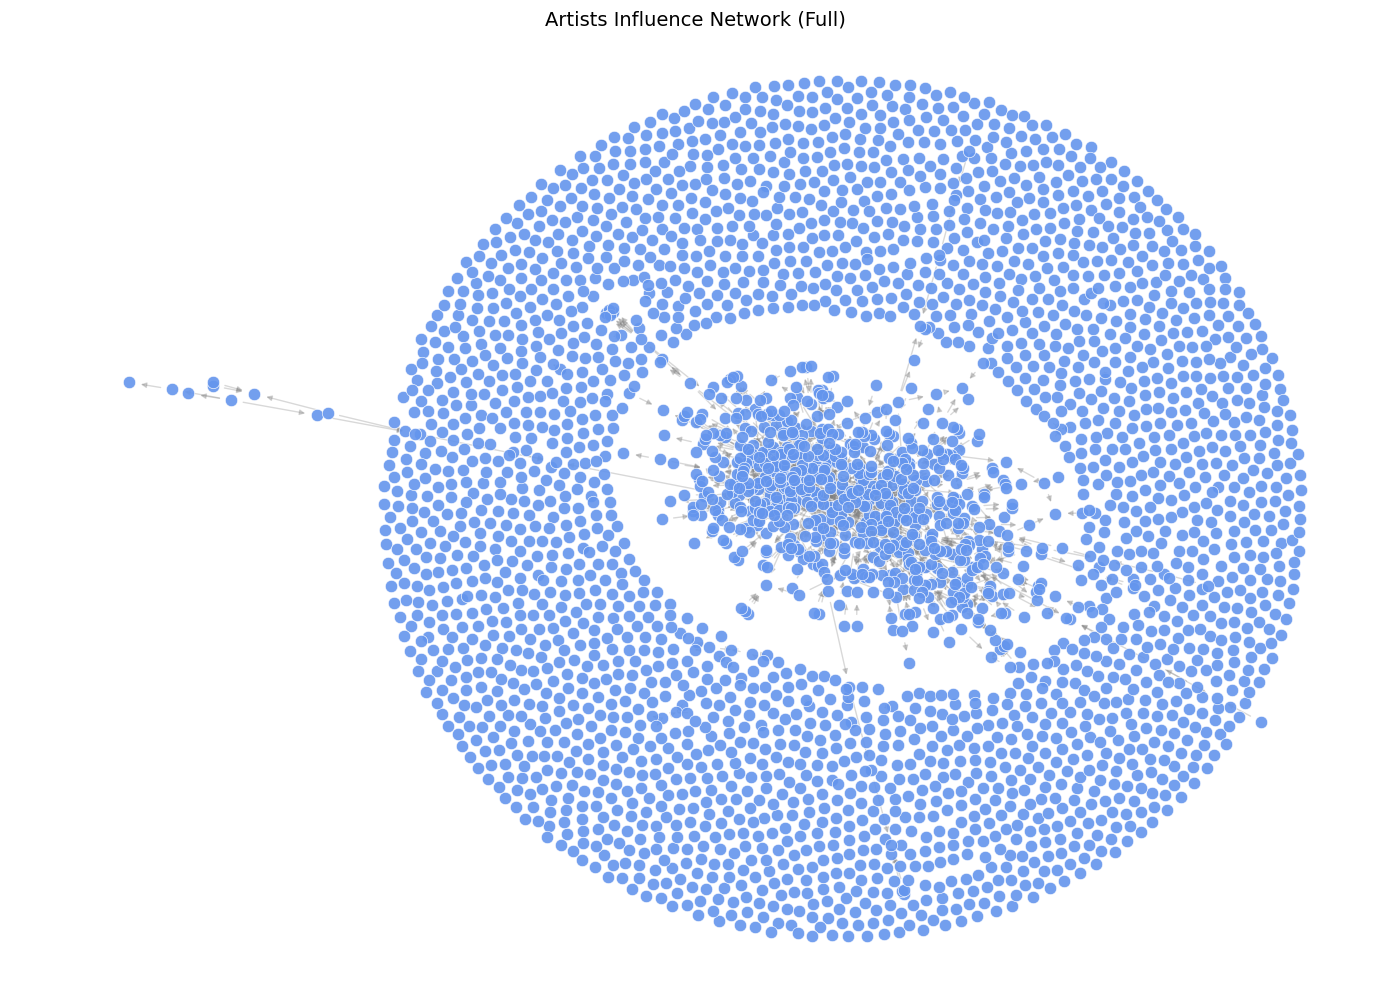

Visualized 3133 nodes and 1383 edges.


In [31]:
visualize_graph(G, "Artists Influence Network (Full)")

Nodes: 3133 ------> 792
Edges: 1383 ------> 1383


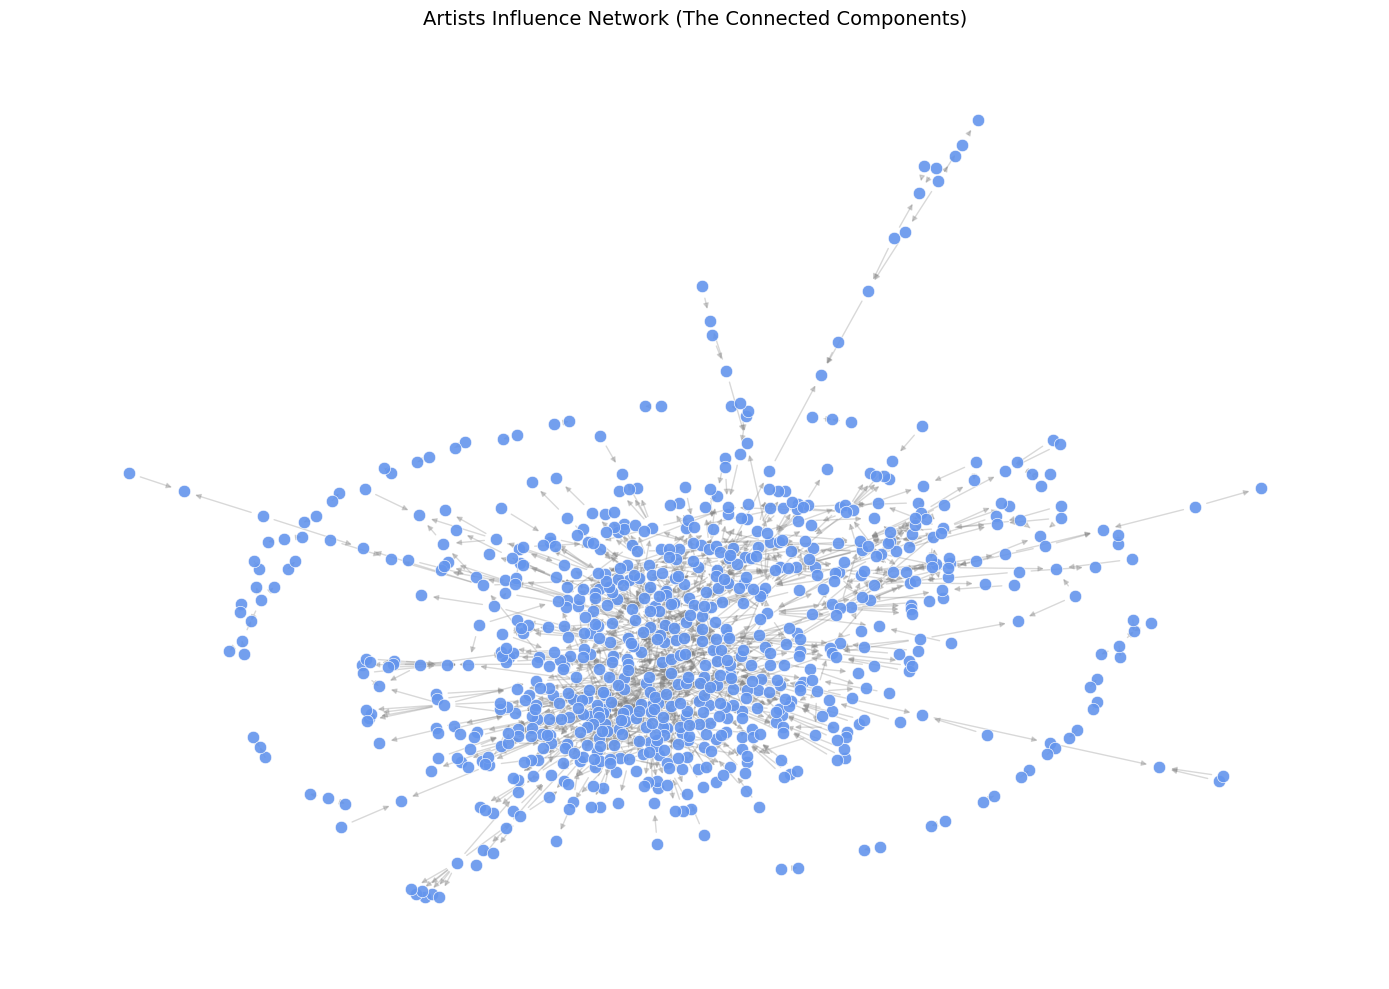

Visualized 792 nodes and 1383 edges.


In [32]:
G_connected = G.subgraph([n for n in G.nodes() if G.degree(n) > 0]).copy()
print("Nodes:", G.number_of_nodes(), "------>", G_connected.number_of_nodes())
print("Edges:", G.number_of_edges(), "------>", G_connected.number_of_edges())

visualize_graph(G_connected, "Artists Influence Network (The Connected Components)")


In [33]:
out_degree = G.out_degree()
sorted_out_degree = sorted(out_degree, key=lambda x: x[1], reverse=True)
top_artists = sorted_out_degree[:20]
top_artists

[('/en/pablo-picasso', 25),
 ('/en/paul-cezanne', 23),
 ('/en/rembrandt', 21),
 ('/en/caravaggio', 21),
 ('/en/titian', 17),
 ('/en/gustave-courbet', 17),
 ('/en/nicolas-poussin', 16),
 ('/en/diego-velazquez', 16),
 ('/en/raphael', 15),
 ('/en/henri-matisse', 15),
 ('/en/michelangelo', 15),
 ('/en/paul-gauguin', 13),
 ('/en/el-greco', 12),
 ('/en/jean-francois-millet', 12),
 ('/en/wassily-kandinsky', 12),
 ('/en/vincent-van-gogh', 12),
 ('/en/peter-paul-rubens', 12),
 ('/en/giotto', 11),
 ('/en/robert-delaunay', 11),
 ('/en/giorgio-de-chirico', 11)]

# Question 2 & 3
**Which were the most influential movements?**

**Which were the most influential institutions?**

In [34]:
G_moveinst = nx.Graph()

for _, row in artists.iterrows():
    G_moveinst.add_node(row['artistUrl'],
               type='artist',
               title=row['title'],
               nation=row['nation'],
               artworks=row['totalWorksTitle'])

for _, row in relationships.iterrows():
    artist_url = row['artistUrl']
    movements = [m.strip() for m in row['movements'].split(',') if m.strip()]
    for m in movements:
        G_moveinst.add_node(m, type='movement')
        G_moveinst.add_edge(artist_url, m)

for _, row in relationships.iterrows():
    artist_url = row['artistUrl']
    institutions = row['institution'].split(',') if isinstance(row['institution'], str) else []
    for m in institutions:
        G_moveinst.add_node(m, type='institution')
        G_moveinst.add_edge(artist_url, m)

components = list(nx.connected_components(G_moveinst))
print(f"Number of connected components: {len(components)}")

component_sizes = sorted([len(c) for c in components], reverse=True)
print("Sizes of components:", component_sizes)

Number of connected components: 55
Sizes of components: [3131, 12, 11, 11, 8, 7, 7, 6, 6, 4, 4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


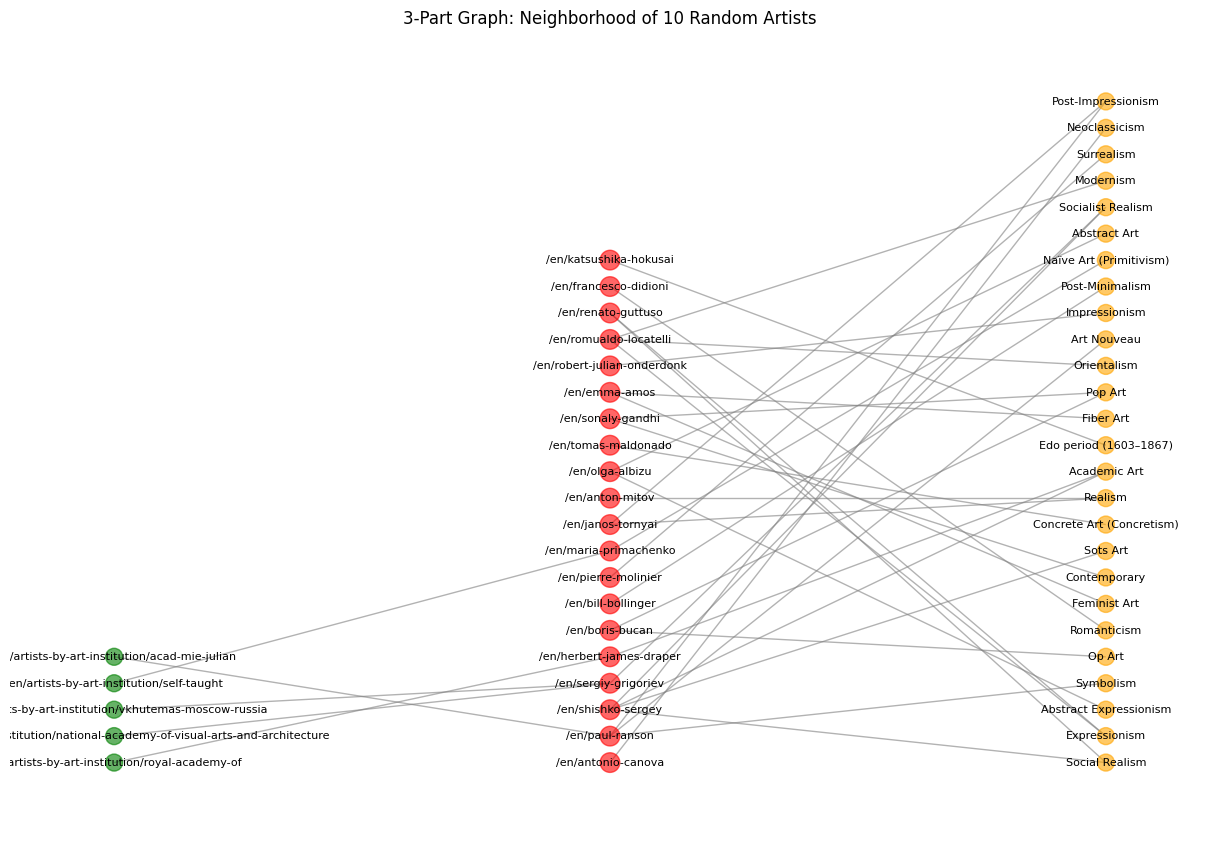

In [35]:
artist_nodes_all = [n for n, attr in G_moveinst.nodes(data=True) if attr['type'] == 'artist']
selected_artists = random.sample(artist_nodes_all, 20)

neighbors = set()
for artist in selected_artists:
    neighbors.update(G_moveinst.neighbors(artist))

sub_nodes = set(selected_artists).union(neighbors)
H = G_moveinst.subgraph(sub_nodes).copy()

artists_nodes = [n for n in H.nodes() if H.nodes[n]['type'] == 'artist']
movements_nodes = [n for n in H.nodes() if H.nodes[n]['type'] == 'movement']
institutions_nodes = [n for n in H.nodes() if H.nodes[n]['type'] == 'institution']

pos = {}
y_artists = list(range(len(artists_nodes)))
y_movements = list(range(len(movements_nodes)))
y_institutions = list(range(len(institutions_nodes)))

np.random.shuffle(y_artists)
np.random.shuffle(y_movements)
np.random.shuffle(y_institutions)

for i, n in enumerate(artists_nodes):
    pos[n] = (0, y_artists[i])  # middle

for i, n in enumerate(movements_nodes):
    pos[n] = (2, y_movements[i])  # right

for i, n in enumerate(institutions_nodes):
    pos[n] = (-2, y_institutions[i])  # left

color_map = []
size_map = []
for node in H.nodes():
    node_type = H.nodes[node]['type']
    if node_type == 'artist':
        if node in selected_artists:
            color_map.append('red')
            size_map.append(200)
        else:
            color_map.append('skyblue')
            size_map.append(50)
    elif node_type == 'movement':
        color_map.append('orange')
        size_map.append(150)
    elif node_type == 'institution':
        color_map.append('green')
        size_map.append(150)
    else:
        color_map.append('grey')
        size_map.append(50)

plt.figure(figsize=(12, 8))
nx.draw(H, pos, node_color=color_map, node_size=size_map, edge_color='gray', alpha=0.6)
labels = {n: n for n in H.nodes()}
nx.draw_networkx_labels(H, pos, labels, font_size=8)

plt.title("3-Part Graph: Neighborhood of 10 Random Artists")
plt.axis('off')
plt.show()


In [36]:
largest_component = max(nx.connected_components(G_moveinst), key=len)
G_lcc = G_moveinst.subgraph(largest_component).copy()

eigen_centrality = nx.eigenvector_centrality_numpy(G_lcc)

top_movements_eigen = {node: score for node, score in eigen_centrality.items() if node in G_lcc.nodes() and G_moveinst.nodes[node]['type'] == 'movement'}
top_movements_eigen = sorted(top_movements_eigen.items(), key=lambda x: x[1], reverse=True)[:10]

top_institutions_eigen = {node: score for node, score in eigen_centrality.items() if node in G_lcc.nodes() and G_moveinst.nodes[node]['type'] == 'institution'}
top_institutions_eigen = sorted(top_institutions_eigen.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Influential Movements (based on Eigenvector Centrality):")
for m, score in top_movements_eigen:
    print(f"{m}: {score:.4f}")

print("\nTop 10 Influential Institutions (based on Eigenvector Centrality):")
for i, score in top_institutions_eigen:
    print(f"{i}: {score:.4f}")

Top 10 Influential Movements (based on Eigenvector Centrality):
Romanticism: 0.5175
Realism: 0.2974
Impressionism: 0.2930
Academic Art: 0.0950
Expressionism: 0.0919
Post-Impressionism: 0.0724
Symbolism: 0.0687
Art Nouveau: 0.0494
Orientalism: 0.0448
Neoclassicism: 0.0422

Top 10 Influential Institutions (based on Eigenvector Centrality):
/en/artists-by-art-institution/cole-des-beaux-arts: 0.1016
/en/artists-by-art-institution/imperial-academy-of-arts-saint-petersburg-russia: 0.0516
/en/artists-by-art-institution/acad-mie-julian: 0.0491
/en/artists-by-art-institution/akademie-der: 0.0331
/en/artists-by-art-institution/royal-academy-of: 0.0319
/en/artists-by-art-institution/art-students-league: 0.0267
/en/artists-by-art-institution/acad-mie-des-beaux: 0.0259
/en/artists-by-art-institution/national-academy: 0.0227
/en/artists-by-art-institution/kunstakademie-dusseldorf-dusseldorf-germany: 0.0168
/en/artists-by-art-institution/pennsylvania-academy: 0.0139


# Question 4
**Which nationalities concentrate the majority of artists?**

In [37]:
nationality_counts = artists['nation'].value_counts()
total_artists = len(artists)
nationality_percent = (nationality_counts / total_artists * 100).round(2)
print("\nTop nationalities (% of total artists):")
print(nationality_percent.head(20))


Top nationalities (% of total artists):
nation
American      17.36
French        13.42
Italian        8.98
British        8.31
German         5.34
Russian        3.60
Dutch          3.50
Spanish        2.90
Romanian       2.60
Japanese       2.24
Ukrainian      1.94
Portuguese     1.74
Swiss          1.57
Austrian       1.54
Chinese        1.44
Flemish        1.34
Polish         1.27
Belgian        1.20
Australian     1.20
Canadian       1.17
Name: count, dtype: float64


# Question 5
**Which are the biggest communities in the network?**

In [38]:
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected)
num_communities = len(set(partition.values()))
print(f"Number of communities found: {num_communities}\n")

communities = defaultdict(list)
for node, com_id in partition.items():
    communities[com_id].append(node)

community_sizes = sorted([(com_id, len(nodes)) for com_id, nodes in communities.items()],
                         key=lambda x: x[1], reverse=True)

print("=== Community Sizes ===")
for com_id, size in community_sizes[:15]:
    print(f"Community {com_id}: {size} nodes")

Number of communities found: 2387

=== Community Sizes ===
Community 461: 119 nodes
Community 54: 85 nodes
Community 507: 62 nodes
Community 100: 56 nodes
Community 655: 55 nodes
Community 42: 49 nodes
Community 396: 40 nodes
Community 259: 39 nodes
Community 761: 39 nodes
Community 743: 38 nodes
Community 671: 34 nodes
Community 109: 30 nodes
Community 197: 20 nodes
Community 462: 17 nodes
Community 546: 13 nodes


Number of large communities (>20 nodes): 12


/tmp/ipython-input-1045091746.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_coms)


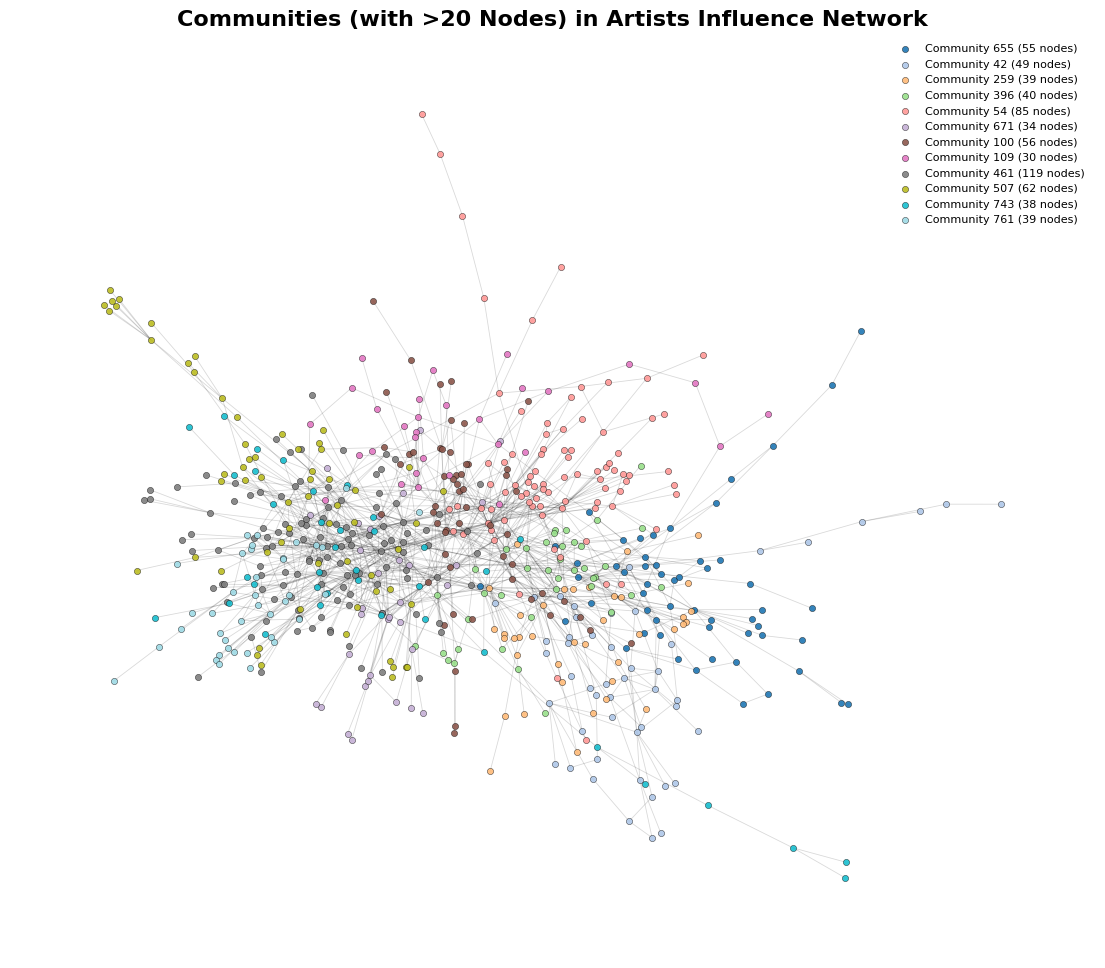

In [39]:
pos = nx.spring_layout(G_undirected, k=0.25, iterations=50, seed=42)
communities_dict = defaultdict(list)
for node, com_id in partition.items():
    communities_dict[com_id].append(node)
large_communities = {com_id: nodes for com_id, nodes in communities_dict.items() if len(nodes) > 20}
print(f"Number of large communities (>20 nodes): {len(large_communities)}")

num_coms = len(large_communities)
cmap = cm.get_cmap('tab20', num_coms)
plt.figure(figsize=(14, 12))
for i, (com_id, list_nodes) in enumerate(large_communities.items()):
    nx.draw_networkx_nodes(
        G_undirected,
        pos,
        nodelist=list_nodes,
        node_size=20,
        node_color=[cmap(i % 20)],  # wrap colors if >20 communities
        label=f'Community {com_id} ({len(list_nodes)} nodes)',
        alpha=0.9,
        edgecolors='black',
        linewidths=0.3
    )

sub_nodes = [n for nodes in large_communities.values() for n in nodes]
subG = G_undirected.subgraph(sub_nodes)
nx.draw_networkx_edges(subG, pos, alpha=0.15, width=0.6)

plt.title("Communities (with >20 Nodes) in Artists Influence Network", fontsize=16, fontweight='bold')
plt.legend(scatterpoints=1, fontsize=8, loc='best', frameon=False)
plt.axis('off')
plt.show()


In [40]:
communities_dict = defaultdict(list)
for node, com_id in partition.items():
    communities_dict[com_id].append(node)

sorted_communities = sorted(communities_dict.items(), key=lambda x: len(x[1]), reverse=True)

print("=== Largest Communities ===\n")
for com_id, nodes in sorted_communities[:2]:
    print(f"Community {com_id}: {len(nodes)} nodes")
    print("  Sample nodes:")
    for n in nodes[:20]:
        print("   ", n)
    print()


=== Largest Communities ===

Community 461: 119 nodes
  Sample nodes:
    /en/arnold-bocklin
    /en/camille-pissarro
    /en/paul-cezanne
    /en/pierre-auguste-renoir
    /en/henri-rousseau
    /en/paul-gauguin
    /en/henri-edmond-cross
    /en/aristide-maillol
    /en/edvard-munch
    /en/leon-bakst
    /en/wassily-kandinsky
    /en/pierre-bonnard
    /en/henri-matisse
    /en/harry-phelan-gibb
    /en/piet-mondrian
    /en/paul-klee
    /en/hans-hofmann
    /en/ernst-ludwig-kirchner
    /en/maria-blanchard
    /en/pablo-picasso

Community 54: 85 nodes
  Sample nodes:
    /en/hans-holbein-the-younger
    /en/pieter-bruegel-the-elder
    /en/paul-bril
    /en/tobias-verhaecht
    /en/adam-van-noort
    /en/charles-jacque
    /en/gustave-courbet
    /en/edward-ladell
    /en/alfred-dehodencq
    /en/oswald-achenbach
    /en/nathaniel-hone-the-younger
    /en/edouard-manet
    /en/carl-bloch
    /en/james-mcneill-whistler
    /en/winslow-homer
    /en/james-tissot
    /en/carolus-dura